# Burned area by source

This notebook reads `outputs/merged_emissions_and_ba.csv` and plots burned area (hectares) over time for multiple sources (VanWees, GFED, ADEC, MODIS, etc). It includes cleaning, aggregation, resampling, and saving outputs.

In [2]:
# Environment & imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [3]:
# Load merged CSV into a DataFrame
from pathlib import Path

merged_fp = Path("outputs") / "merged_emissions_and_ba.csv"
df = pd.read_csv(merged_fp, low_memory=False)
df.head()

,year,carbon_emissions_GFED5.1_ecosystem,burned_area_ha_GFED5.1_ecosystem,C_GFED5.1_monthly,CH4_GFED5.1_monthly,CO_GFED5.1_monthly,CO2_GFED5.1_monthly,DM_GFED5.1_monthly,N2O_GFED5.1_monthly,C_AG_TOT_VanWees,...,burned_area_ha_WFEIS,emissions_co2_g_WFEIS,emissions_ch4_g_WFEIS,emissions_co_g_WFEIS,emissions_c_g_WFEIS,burned_area_ha_WFIGS_Archive,emissions_co2_g_WFIGS_Archive,emissions_ch4_g_WFIGS_Archive,emissions_co_g_WFIGS_Archive,emissions_c_g_WFIGS_Archive
0,1940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clean & standardize burned-area columns (no long/wide transforms needed)
ba_cols = [c for c in df.columns if c.startswith("burned_area_ha")]

# Normalize column names: remove prefix and tidy
col_renames = {
    c: c.replace("burned_area_ha_", "").lower().replace(".", "_").replace(" ", "_")
    for c in ba_cols
}

# Map known aliases to friendly names
alias_map = {
    "gfed5_1_ecosystem": "gfed",
    "gfed5_1_monthly": "gfed_monthly",
    "vanwees": "vanwees",
    "vanwees_500m": "vanwees_500m",
    "modis_lara": "modis_lara",
    "modis_total": "modis_total",
    "adec": "adec",
    "perimeters": "fire_perimeters",
    "peat_perimeters": "fire_perimeters_peat",
    "wfeis": "wfeis",
    "wfigs_archive": "wfigs_archive",
}
# Apply alias mapping where applicable and create final renames
final_renames = {old: alias_map.get(new, new) for old, new in col_renames.items()}

# Create a cleaned wide-format DataFrame: one column per source
df_ba = df[["year"] + ba_cols].rename(columns=final_renames)
ba_cols_renamed = list(final_renames.values())

# Convert burned-area columns to numeric and drop rows where all sources are missing
df_ba[ba_cols_renamed] = df_ba[ba_cols_renamed].apply(pd.to_numeric, errors="coerce")
df_ba = df_ba.dropna(subset=ba_cols_renamed, how="all").reset_index(drop=True)

df_ba["date"] = pd.to_datetime(df_ba["year"].astype(int), format="%Y")
df_ba = df_ba.set_index("date")

print("Rows after cleaning:", df_ba.shape[0])
df_ba.head()


Rows after cleaning: 81


,year,gfed,vanwees,vanwees500m,vanwees500m_peat,modis_lara,modis_total,adec,fire_perimeters,fire_perimeters_peat,wfeis,wfigs_archive
date,,,,,,,,,,,,
1940-01-01,1940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5206.430592,404.24,NaN,NaN
1942-01-01,1942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11519.195040,248.20,NaN,NaN
1943-01-01,1943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98581.048230,17755.72,NaN,NaN
1944-01-01,1944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38907.340150,9830.68,NaN,NaN
1946-01-01,1946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,156920.932100,17498.40,NaN,NaN


In [5]:
# Compute error metrics against ADEC (assumed truth)
# Metrics: bias, MAE, RMSE, MAPE, R2. Only years where both ADEC and the model have non-null values are used.
truth = "adec"
model_cols = [
    "fire_perimeters",
    "wfeis",
    "gfed",
    "vanwees500m",
    "modis_total",
]
# model_cols = ['fire_perimeters']

metrics = []
for model in model_cols:
    comp = df_ba[(df_ba["year"] >= 0) & (df_ba["year"] <= 20205)][
        [truth, model]
    ].dropna()

    y_true = comp[truth]
    y_pred = comp[model]
    diff = y_pred - y_true

    bias = diff.mean()
    mae = diff.abs().mean()
    rmse = np.sqrt((diff**2).mean())

    mape = (diff.abs() / y_true).mean() * 100

    # R^2 (coefficient of determination)
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()

    metrics.append(
        {
            "source": model,
            "bias_ha": bias,
            "mae_ha": mae,
            "rmse_ha": rmse,
            "mape_pct": mape,
        }
    )

metrics_df = pd.DataFrame(metrics).set_index("source")

# Rename columns and rows for prettier output
metrics_df.columns = ["Bias (ha)", "MAE (ha)", "RMSE (ha)", "MAPE (%)"]
metrics_df.index.name = "Source"

# Map model names to prettier display names
display_names = {
    "fire_perimeters": "AICC",
    "wfeis": "WFEIS-MTBS",
    "gfed": "GFED 5.1",
    "vanwees500m": "van Wees et al. (2022)",
    "modis_total": "MODIS MCD64A1",
}
metrics_df = metrics_df.rename(index=display_names)

# Save and display
out_metrics_fp = Path("outputs") / "error_metrics_vs_adec.csv"
metrics_df.to_csv(out_metrics_fp)
print("Saved error metrics to", out_metrics_fp)
metrics_df


Saved error metrics to outputs\error_metrics_vs_adec.csv


,Bias (ha),MAE (ha),RMSE (ha),MAPE (%)
Source,,,,
AICC,-4135.944197,15822.896364,24223.564321,5.616674
WFEIS-MTBS,-18697.224167,36327.514500,49615.197513,9.495539
GFED 5.1,-54426.551643,79582.835087,144596.754720,17.500987
van Wees et al. (2022),-131419.330837,131419.330837,177592.229828,34.729404
MODIS MCD64A1,-213229.356935,213229.356935,297046.903709,48.050188


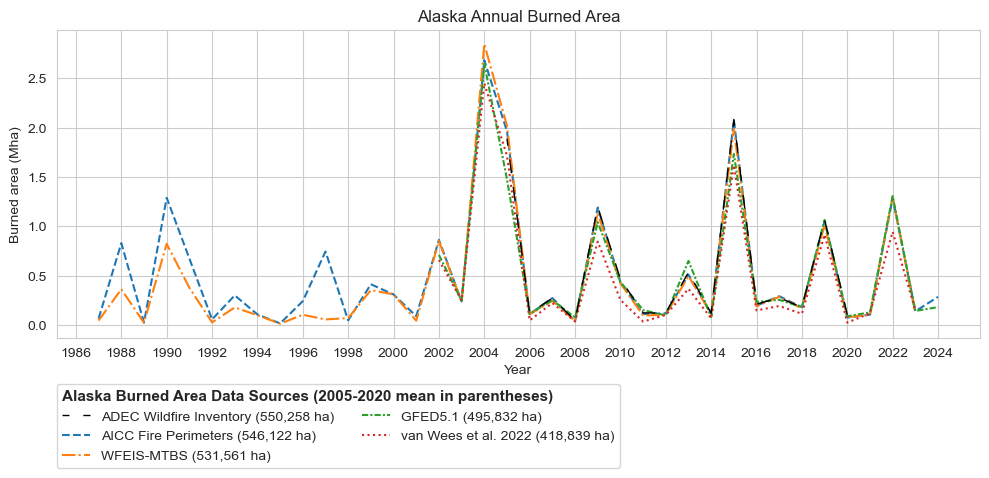


95% Confidence Intervals for Burned Area (2005-2020):
         Source     Mean (ha)      Std (ha)   95% CI (ha)  Lower limit (ha)  Upper limit (ha)  N years
           adec 550258.099167 654787.054656 320845.656781     229412.442385     871103.755948       16
fire_perimeters 546122.154970 666271.974368 326473.267440     219648.887530     872595.422410       16
          wfeis 531560.875000 659024.987235 322922.243745     208638.631255     854483.118745       16
           gfed 495831.547524 539724.537628 264465.023438     231366.524086     760296.570961       16
    vanwees500m 418838.768329 556956.772267 272908.818411     145929.949919     691747.586740       16


In [6]:
plt.figure(figsize=(10, 5))
plot_cols = [
    "adec",
    "fire_perimeters",
    "wfeis",
    "gfed",
    "vanwees500m",
    # "modis_total",
]
df_plot = df_ba[plot_cols].dropna(how="all")
df_plot = df_plot[(df_plot.index.year >= 1987) & (df_plot.index.year <= 2025)]

# Calculate means for 2005-2020 only
means_2005_2020 = df_plot.loc[
    (df_plot.index.year >= 2005) & (df_plot.index.year <= 2020)
].mean()

legend_labels = [
    f"ADEC Wildfire Inventory ({means_2005_2020['adec']:,.0f} ha)",
    f"AICC Fire Perimeters ({means_2005_2020['fire_perimeters']:,.0f} ha)",
    f"WFEIS-MTBS ({means_2005_2020['wfeis']:,.0f} ha)",
    f"GFED5.1 ({means_2005_2020['gfed']:,.0f} ha)",
    f"van Wees et al. 2022 ({means_2005_2020['vanwees500m']:,.0f} ha)",
    # f"MODIS MCD64A1 ({means_2005_2020['modis_total']:,.0f} ha)",
]

linestyles = [(5, (10, 10)), "--", "-.", (0, (3, 1, 1, 1)), ":", (5, (10, 3)), (0, (1, 1))]

# Plot lines
for i, col in enumerate(plot_cols[1:]):
    plt.plot(
        df_plot.index.year,
        df_plot[col] / 1e6,
        label=legend_labels[i + 1],
        linestyle=linestyles[i + 1],
    )
plt.plot(
    df_plot.index.year,
    df_plot["adec"] / 1e6,
    label=legend_labels[0],
    linestyle=linestyles[0],
    color="black",
    linewidth=1,
)

plt.title("Alaska Annual Burned Area", fontsize=12)
plt.ylabel("Burned area (Mha)")
plt.xlabel("Year")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

# Legend above plot, below titles
handles, labels = plt.gca().get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
ordered_handles = [
    label_to_handle[lbl] for lbl in legend_labels if lbl in label_to_handle
]
ordered_labels = [lbl for lbl in legend_labels if lbl in label_to_handle]

plt.legend(
    ordered_handles,
    ordered_labels,
    loc="upper left",
    bbox_to_anchor=(0, -0.15),
    borderaxespad=0.0,
    ncol=2,
    fontsize=10,
    title="Alaska Burned Area Data Sources (2005-2020 mean in parentheses)",
    title_fontproperties={"weight": "bold", "size": 11},
    alignment="left"
)

plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_burned_area_by_source.png")
plt.show()

# Calculate 95% confidence intervals for each series (2005-2020)
df_ci = df_plot[(df_plot.index.year >= 2005) & (df_plot.index.year <= 2020)].copy()

ci_results = []
for col in plot_cols:
    data = df_ci[col].dropna()
    if len(data) > 0:
        mean = data.mean()
        std = data.std()
        n = len(data)
        ci95 = 1.96 * std / np.sqrt(n)
        ci_results.append({
            'Source': col,
            'Mean (ha)': mean,
            'Std (ha)': std,
            '95% CI (ha)': ci95,
            'Lower limit (ha)': mean - ci95,
            'Upper limit (ha)': mean + ci95,
            'N years': n
        })

ci_df = pd.DataFrame(ci_results)
print("\n95% Confidence Intervals for Burned Area (2005-2020):")
print(ci_df.to_string(index=False))


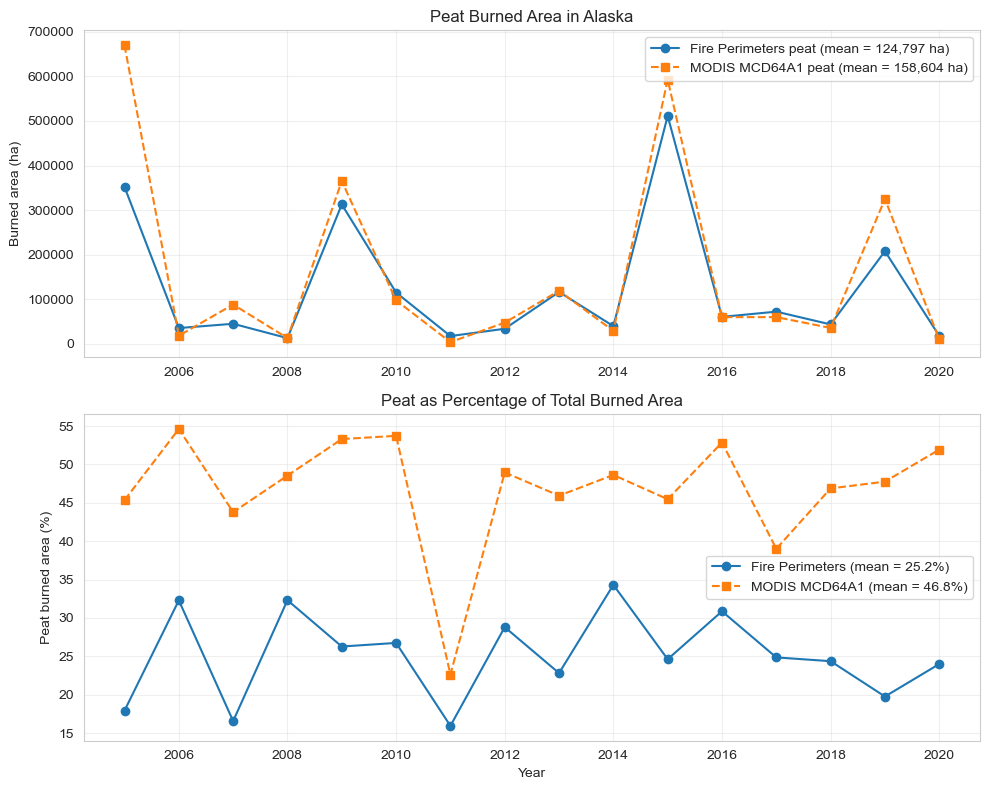


Fire Perimeters - Mean peat burned area: 124,797 ha (25.2% of total)
MODIS MCD64A1 - Mean peat burned area: 158,604 ha (46.8% of total)


In [28]:
# Plot peat burned area in absolute terms and as percentage of total
import matplotlib.pyplot as plt

# Prepare data
df_peat = df[
    [
        "year",
        "burned_area_ha_peat_Perimeters",
        "burned_area_ha_MODIS_Lara",
        "burned_area_ha_Perimeters",
        "burned_area_ha_MODIS_Total",
    ]
].copy()
df_peat = df_peat.dropna(
    subset=["burned_area_ha_peat_Perimeters", "burned_area_ha_MODIS_Lara"], how="all"
)

# Filter for years after 2000
df_peat = df_peat[(df_peat["year"] >= 2005) & (df_peat["year"] <= 2020)]

# Calculate percentages
df_peat["peat_pct_Perimeters"] = (
    df_peat["burned_area_ha_peat_Perimeters"] / df_peat["burned_area_ha_Perimeters"]
) * 100
df_peat["peat_pct_MODIS"] = (
    df_peat["burned_area_ha_MODIS_Lara"] / df_peat["burned_area_ha_MODIS_Total"]
) * 100

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Absolute area (ha) with mean in legend
mean_perimeters = df_peat["burned_area_ha_peat_Perimeters"].mean()
mean_modis = df_peat["burned_area_ha_MODIS_Lara"].mean()

ax1.plot(
    df_peat["year"],
    df_peat["burned_area_ha_peat_Perimeters"],
    label=f"Fire Perimeters peat (mean = {mean_perimeters:,.0f} ha)",
    marker="o",
    linestyle="-",
)
ax1.plot(
    df_peat["year"],
    df_peat["burned_area_ha_MODIS_Lara"],
    label=f"MODIS MCD64A1 peat (mean = {mean_modis:,.0f} ha)",
    marker="s",
    linestyle="--",
)
ax1.set_title("Peat Burned Area in Alaska")
ax1.set_ylabel("Burned area (ha)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Percentage of total with mean in legend
mean_pct_perimeters = df_peat["peat_pct_Perimeters"].mean()
mean_pct_modis = df_peat["peat_pct_MODIS"].mean()

ax2.plot(
    df_peat["year"],
    df_peat["peat_pct_Perimeters"],
    label=f"Fire Perimeters (mean = {mean_pct_perimeters:.1f}%)",
    marker="o",
    linestyle="-",
)
ax2.plot(
    df_peat["year"],
    df_peat["peat_pct_MODIS"],
    label=f"MODIS MCD64A1 (mean = {mean_pct_modis:.1f}%)",
    marker="s",
    linestyle="--",
)
ax2.set_title("Peat as Percentage of Total Burned Area")
ax2.set_ylabel("Peat burned area (%)")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_peat_burned_area.png")
plt.show()

# Print summary statistics
print(
    f"\nFire Perimeters - Mean peat burned area: {df_peat['burned_area_ha_peat_Perimeters'].mean():,.0f} ha ({df_peat['peat_pct_Perimeters'].mean():.1f}% of total)"
)
print(
    f"MODIS MCD64A1 - Mean peat burned area: {df_peat['burned_area_ha_MODIS_Lara'].mean():,.0f} ha ({df_peat['peat_pct_MODIS'].mean():.1f}% of total)"
)


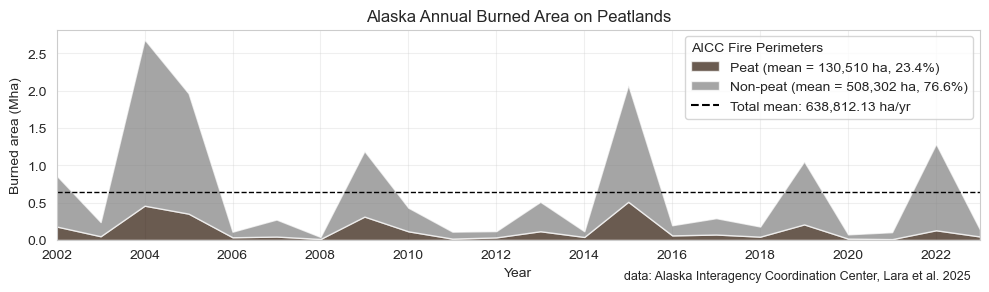


Peat Burned Area Statistics (2002-2023):
Mean: 130,510 ha
  Standard deviation: ±148,131 ha
  95% confidence interval: ±61,900 ha

Peat as % of Total:
Mean: 23.4%
  Standard deviation: ±7.0%
  95% confidence interval: ±2.9%


In [ ]:
# Stacked area chart: Total vs Peat burned area (Fire Perimeters) with ADEC overlay
# Prepare data for 2005-2024
df_stacked = df[
    ["year", "burned_area_ha_Perimeters", "burned_area_ha_peat_Perimeters"]
].copy()
df_stacked = df_stacked[(df_stacked["year"] >= 2002) & (df_stacked["year"] <= 2023)]
df_stacked = df_stacked.dropna(
    subset=["burned_area_ha_Perimeters", "burned_area_ha_peat_Perimeters"]
)

# Calculate non-peat area for stacking
df_stacked["non_peat_ha"] = (
    df_stacked["burned_area_ha_Perimeters"]
    - df_stacked["burned_area_ha_peat_Perimeters"]
)

# Calculate mean values and percentages
mean_peat_ha = df_stacked["burned_area_ha_peat_Perimeters"].mean()
mean_non_peat_ha = df_stacked["non_peat_ha"].mean()
mean_total_ha = mean_peat_ha + mean_non_peat_ha
peat_pct = 100 * (
    df_stacked["burned_area_ha_peat_Perimeters"]
    / df_stacked["burned_area_ha_Perimeters"]
)
non_peat_pct = 100 * (
    df_stacked["non_peat_ha"] / df_stacked["burned_area_ha_Perimeters"]
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 3))

# Stacked area chart (without labels in stackplot)
ax.stackplot(
    df_stacked["year"],
    df_stacked["burned_area_ha_peat_Perimeters"] / 1e6,
    df_stacked["non_peat_ha"] / 1e6,
    alpha=0.7,
    colors=["#2B1506", "tab:gray"],
)

# Long-term averages
ax.axhline(
    mean_total_ha / 1e6,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {mean_total_ha:,.2f} ha/yr",
)

# Create custom legend with mean values and percentages
legend_elements = [
    Patch(
        facecolor="#2B1506", 
        alpha=0.7,
        label=f"Peat (mean = {mean_peat_ha:,.0f} ha, {peat_pct.mean():.1f}%)",
    ),
    Patch(
        facecolor="tab:gray",
        alpha=0.7,
        label=f"Non-peat (mean = {mean_non_peat_ha:,.0f} ha, {non_peat_pct.mean():.1f}%)",
    ),
    Line2D(
        [0], [0], color="black", linestyle="--", label=f"Total mean: {mean_total_ha:,.2f} ha/yr"
    ),
]

leg = ax.legend(
    handles=legend_elements,
    loc="upper right",
    title="AICC Fire Perimeters",
    alignment="left",
)

ax.set_title("Alaska Annual Burned Area on Peatlands")
ax.set_ylabel("Burned area (Mha)")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_xlim(2002, 2023)
plt.tight_layout()

# Add annotation in lower right
plt.annotate(
    "data: Alaska Interagency Coordination Center, Lara et al. 2025",
    xy=(0.99, -0.2),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.savefig(Path("outputs") / "plots" / "alaska_stacked_burned_area_peat_vs_total.png")
plt.show()

# Calculate 95% confidence intervals for peat burned area and percentage (2002-2023)
peat_ha_series = df_stacked["burned_area_ha_peat_Perimeters"]
peat_pct_series = peat_pct

# Standard deviations
std_peat_ha = peat_ha_series.std()
std_peat_pct = peat_pct_series.std()

# 95% confidence intervals (mean ± 1.96 * std / sqrt(n))
n_years = len(df_stacked)
ci95_peat_ha = 1.96 * std_peat_ha / np.sqrt(n_years)
ci95_peat_pct = 1.96 * std_peat_pct / np.sqrt(n_years)

print("\nPeat Burned Area Statistics (2002-2023):")
print(f"Mean: {mean_peat_ha:,.0f} ha")
print(f"  Standard deviation: ±{std_peat_ha:,.0f} ha")
print(f"  95% confidence interval: ±{ci95_peat_ha:,.0f} ha")
print("\nPeat as % of Total:")
print(f"Mean: {peat_pct.mean():.1f}%")
print(f"  Standard deviation: ±{std_peat_pct:.1f}%")
print(f"  95% confidence interval: ±{ci95_peat_pct:.1f}%")

In [255]:
# Calculate emissions time series from IPCC & peat burned area (Fire Perimeters)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# IPCC Input parameters
dry_matter_per_ha = 66000  # kg DM/ha
co2_per_kg_dm = 362 * 44 / 12  # grams/kg
co_per_kg_dm = 209  # grams/kg
ch4_per_kg_dm = 9  # grams/kg

# Global Warming Potentials (100-year)
gwp_co2 = 1
gwp_co = 1.9
gwp_ch4 = 28

# Load peat burned area data from perimeters
# Assuming 'df' contains 'peat_area_ha' column from Fire Perimeters
df_emissions = df[["burned_area_ha_peat_Perimeters", "year"]].copy() 
df_emissions = df_emissions.rename(columns={"burned_area_ha_peat_Perimeters": "peat_area_ha"})
df_emissions = df_emissions.set_index("year").sort_index()

# Calculate emissions for each year
emissions_data = []

for year in df_emissions.index:
    peat_area_ha = df_emissions.loc[year, "peat_area_ha"]

    # Total dry matter burned (kg)
    total_dm_kg = peat_area_ha * dry_matter_per_ha

    # Emissions by gas (grams)
    co2_emissions_g = total_dm_kg * co2_per_kg_dm
    co_emissions_g = total_dm_kg * co_per_kg_dm
    ch4_emissions_g = total_dm_kg * ch4_per_kg_dm

    # Convert to tonnes and apply GWPs for CO2e
    co2_co2e = (co2_emissions_g / 1e6) * gwp_co2  # tonnes CO2e
    co_co2e = (co_emissions_g / 1e6) * gwp_co # tonnes CO2e
    ch4_co2e = (ch4_emissions_g / 1e6) * gwp_ch4 # tonnes CO2e

    total_co2e = co2_co2e + ch4_co2e #+ co_co2e

    emissions_data.append(
        {
            "year": year,
            "peat_area_ha": peat_area_ha,
            "peat_CO2_tCO2e": co2_co2e,
            "peat_CO_tCO2e": co_co2e,
            "peat_CH4_tCO2e": ch4_co2e,
            "peat_tCO2e": total_co2e,
        }
    )

emissions_df = pd.DataFrame(emissions_data)

# Save emissions data to CSV
emissions_df.to_csv("outputs/peat_emissions_timeseries_from_perimeters.csv", index=False)
print("\nSaved emissions data to peat_emissions_timeseries_from_perimeters.csv")


Saved emissions data to peat_emissions_timeseries_from_perimeters.csv


Saved plot to outputs/plots/peat_emissions_perimeters.png


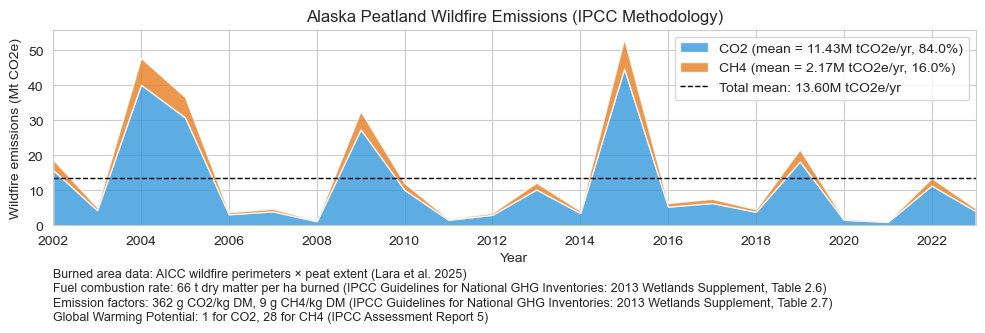

Mean total annual peat emissions (2000-2024): 13.60 ± 15.4 Mt CO2e (std)
95% confidence interval: 13.6 ± 6.5 Mt CO2e


In [300]:
df_e_plot = emissions_df.copy()
df_e_plot = df_e_plot.reset_index()
df_e_plot = df_e_plot[(df_e_plot["year"] >= 2002) & (df_e_plot["year"] <= 2023)]

# Average emissions for annotation
avg_co2e = df_e_plot["peat_tCO2e"].mean()
avg_co_pct = (100 * df_e_plot["peat_CO_tCO2e"] / df_e_plot["peat_tCO2e"]).mean()
avg_ch4_pct = (100 * df_e_plot["peat_CH4_tCO2e"] / df_e_plot["peat_tCO2e"]).mean()
avg_co2_pct = (100 * df_e_plot["peat_CO2_tCO2e"] / df_e_plot["peat_tCO2e"]).mean()
avg_co = df_e_plot["peat_CO_tCO2e"].mean() / 1e6
avg_ch4 = df_e_plot["peat_CH4_tCO2e"].mean() / 1e6
avg_co2 = df_e_plot["peat_CO2_tCO2e"].mean() / 1e6

# Create comprehensive visualization
plt.subplots(figsize=(10, 4))

# Stacked area chart showing gas breakdown
plt.stackplot(
    df_e_plot["year"],
    df_e_plot["peat_CO2_tCO2e"] / 1e6,
    # df_e_plot["peat_CO_tCO2e"] / 1e6,
    df_e_plot["peat_CH4_tCO2e"] / 1e6,
    labels=[
        f"CO2 (mean = {avg_co2:,.2f}M tCO2e/yr, {avg_co2_pct:.1f}%)",
        # f"CO (mean = {avg_co:,.2f}M tCO2e/yr, {avg_co_pct:.1f}%)",
        f"CH4 (mean = {avg_ch4:,.2f}M tCO2e/yr, {avg_ch4_pct:.1f}%)",
    ],
    colors=["#3498db", "#e67e22"],  # , "#e74c3c"],
    alpha=0.8,
)
# Long-term averages
plt.axhline(
    avg_co2e / 1e6,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {avg_co2e / 1e6:,.2f}M tCO2e/yr",
)
plt.xlim(2002, 2023)
plt.xlabel("Year")
plt.ylabel("Wildfire emissions (Mt CO2e)")
plt.title("Alaska Peatland Wildfire Emissions (IPCC Methodology)")
plt.legend(loc="upper right")
# plt.grid(True, alpha=0.3, axis="y")
# plt.xlim(df_e_plot["year"].min() - 1, df_e_plot["year"].max() + 1)
""
# Add annotation in lower right
plt.annotate(
    # "Calculations: 2013 Supplement to the 2006 IPCC\nGuidelines for National Greenhouse Gas Inventories",
    "Burned area data: AICC wildfire perimeters × peat extent (Lara et al. 2025) \n"
    "Fuel combustion rate: 66 t dry matter per ha burned (IPCC Guidelines for National GHG Inventories: 2013 Wetlands Supplement, Table 2.6)\n"
    "Emission factors: 362 g CO2/kg DM, 9 g CH4/kg DM (IPCC Guidelines for National GHG Inventories: 2013 Wetlands Supplement, Table 2.7)\n"
    "Global Warming Potential: 1 for CO2, 28 for CH4 (IPCC Assessment Report 5)",
    xy=(0, -0.5),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=9,
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(
    "outputs/plots/peat_emissions_perimeters.png",
    dpi=300,
    bbox_inches="tight",
)
print("Saved plot to outputs/plots/peat_emissions_perimeters.png")
plt.show()

# Calculate uncertainty around the mean (standard deviation and 95% confidence interval) for total annual peat emissions (Mt CO2e) for 2000-2024
total_co2e_Mt = df_e_plot.loc[df_e_plot["year"].between(2002, 2023), "peat_tCO2e"] / 1e6
mean_total = total_co2e_Mt.mean()
std_total = total_co2e_Mt.std()
n = len(total_co2e_Mt)
# 95% confidence interval (mean ± 1.96 * std / sqrt(n))
ci95 = 1.96 * std_total / np.sqrt(n)
print(f"Mean total annual peat emissions (2000-2024): {mean_total:,.2f} ± {std_total:,.1f} Mt CO2e (std)")
print(f"95% confidence interval: {mean_total:,.1f} ± {ci95:,.1f} Mt CO2e")



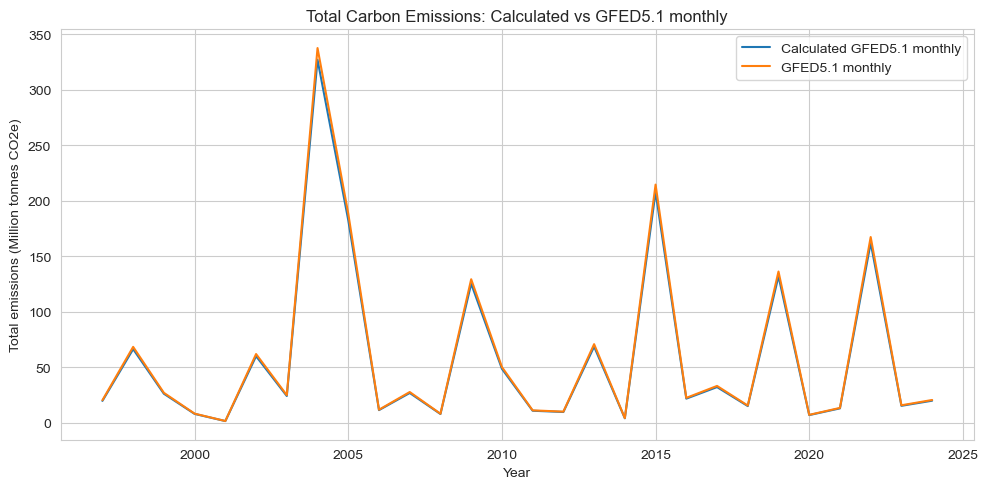

In [ ]:
# Plot sum of C_AG_TOT_VanWees and C_BG_TOT_VanWees vs C_GFED5.1_monthly
df_c = df[["year", "C_GFED5.1_monthly", "CO2_GFED5.1_monthly", "CH4_GFED5.1_monthly"]].copy()
df_c["CO2e_calcd_GFED5.1_monthly"] = df["CO2_GFED5.1_monthly"] + df["CH4_GFED5.1_monthly"] * 27
df_c["CO2e_fromC_GFED5.1_monthly"] = df["C_GFED5.1_monthly"] * 44 / 12

plt.figure(figsize=(10, 5))
plt.plot(df_c["year"], df_c["CO2e_calcd_GFED5.1_monthly"] / 1e12, label="Calculated GFED5.1 monthly")
plt.plot(df_c["year"], df_c["CO2e_fromC_GFED5.1_monthly"] / 1e12, label="GFED5.1 monthly")
plt.title("Total Carbon Emissions: Calculated vs GFED5.1 monthly")
plt.ylabel("Total emissions (Million tonnes CO2e)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()


Saved plot to outputs/plots/alaska_wildfire_emissions_gfed.png


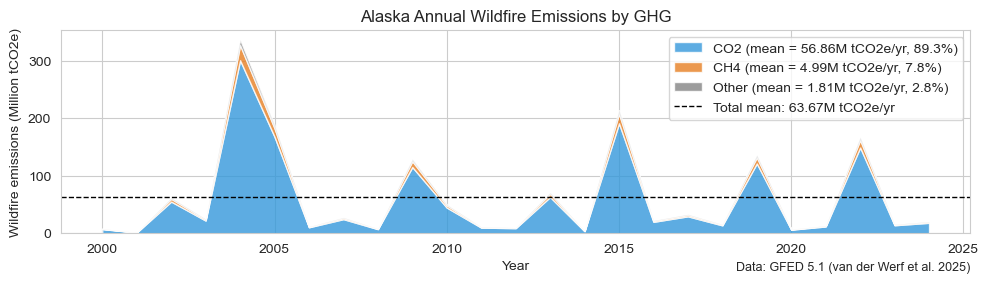

In [76]:
# GFED 5 Wildfire emissions by gas
df_c = df[
    ["year", "C_GFED5.1_monthly", "CO2_GFED5.1_monthly", "CH4_GFED5.1_monthly"]
].copy()
df_c = df_c[df_c["year"] >= 2000]
df_c["CH4_CO2e_GFED5.1_monthly"] = df["CH4_GFED5.1_monthly"] * 28
df_c["C_CO2e_GFED5.1_monthly"] = df["C_GFED5.1_monthly"] * 44 / 12
df_c["OTHER_CO2e_GFED5.1_monthly"] = (
    df_c["C_CO2e_GFED5.1_monthly"]
    - df_c["CO2_GFED5.1_monthly"]
    - df_c["CH4_CO2e_GFED5.1_monthly"]
)

mean_ch4_co2e = df_c["CH4_CO2e_GFED5.1_monthly"].mean() / 1e12
mean_co2 = df_c["CO2_GFED5.1_monthly"].mean() / 1e12
mean_co2e = (
    df_c["C_CO2e_GFED5.1_monthly"]
).mean() / 1e12

# Create comprehensive visualization
plt.subplots(figsize=(10, 3))

# Stacked area chart showing gas breakdown
plt.stackplot(
    df_c["year"],
    df_c["CO2_GFED5.1_monthly"] / 1e12,
    df_c["CH4_CO2e_GFED5.1_monthly"] / 1e12,
    df_c["OTHER_CO2e_GFED5.1_monthly"] / 1e12,
    labels=[
        f"CO2 (mean = {mean_co2:,.2f}M tCO2e/yr, {mean_co2 / mean_co2e:.1%})",
        f"CH4 (mean = {mean_ch4_co2e:,.2f}M tCO2e/yr, {mean_ch4_co2e / mean_co2e:.1%})",
        f"Other (mean = {(mean_co2e - mean_co2 - mean_ch4_co2e):,.2f}M tCO2e/yr, {(mean_co2e - mean_co2 - mean_ch4_co2e) / mean_co2e:.1%})",
    ],
    colors=["#3498db", "#e67e22", "#838383"],
    alpha=0.8,
)
# Long-term averages
plt.axhline(
    mean_co2e,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {mean_co2e:,.2f}M tCO2e/yr",
)
plt.xlabel("Year")
plt.ylabel("Wildfire emissions (Million tCO2e)")
plt.title("Alaska Annual Wildfire Emissions by GHG")
plt.legend(loc="upper right")

# Add annotation in lower right
plt.annotate(
    # "Calculations: 2013 Supplement to the 2006 IPCC\nGuidelines for National Greenhouse Gas Inventories",
    "Data: GFED 5.1 (van der Werf et al. 2025)",
    xy=(1, -0.2),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()

plt.savefig(
    "outputs/plots/alaska_wildfire_emissions_gfed.png",
    dpi=300,
    bbox_inches="tight",
)
print("Saved plot to outputs/plots/alaska_wildfire_emissions_gfed.png")
plt.show()


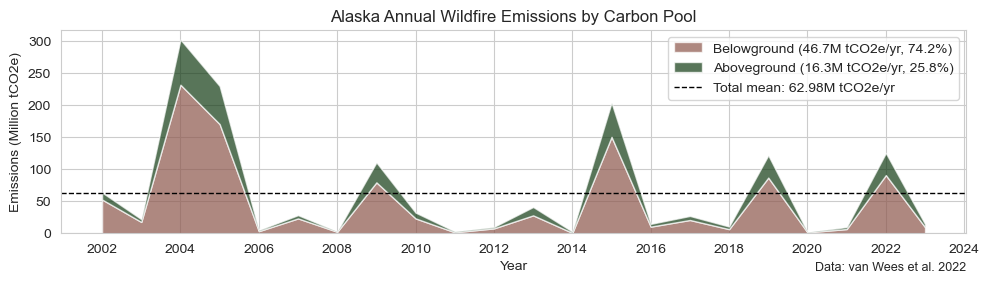


Belowground Proportion of Total Emissions (2002-2023):
Mean: 70.4%
Standard deviation: ±11.5%
95% confidence interval: ±4.8%


In [292]:
# Stacked line plot of C_AG_TOT_VanWees and C_BG_TOT_VanWees, with long-term averages
cols = ["C_AG_TOT_VanWees", "C_BG_TOT_VanWees"]
de_e = df[["year"] + cols].dropna(subset=cols, how="all").copy()
de_e = de_e.sort_values("year")
ag = de_e["C_AG_TOT_VanWees"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
bg = de_e["C_BG_TOT_VanWees"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
years = de_e["year"]

# Stacked line plot
plt.figure(figsize=(10, 3))
ag_mean = ag.mean()
bg_mean = bg.mean()
plt.stackplot(
    years,
    bg,
    ag,
    labels=[
        f"Belowground ({bg_mean:,.1f}M tCO2e/yr, {bg_mean / (ag_mean + bg_mean):.1%})",
        f"Aboveground ({ag_mean:,.1f}M tCO2e/yr, {ag_mean / (ag_mean + bg_mean):.1%})",
    ],
    alpha=0.7,
    colors=["tab:brown", "#113A13"],
)
# Long-term averages
plt.axhline(
    bg_mean + ag_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {bg_mean + ag_mean:,.2f}M tCO2e/yr",
)
plt.title("Alaska Annual Wildfire Emissions by Carbon Pool")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.legend(loc="upper right")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

# Add annotation in lower right
plt.annotate(
    "Data: van Wees et al. 2022",
    xy=(1, -0.2),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_wildfire_emissions_vanwees.png")
plt.show()

# Calculate statistics for belowground proportion (2002-2023)
de_e_stats = de_e[(de_e["year"] >= 2002) & (de_e["year"] <= 2023)].copy()
ag_stats = de_e_stats["C_AG_TOT_VanWees"].fillna(0) / 1000000000000 * 44 / 12
bg_stats = de_e_stats["C_BG_TOT_VanWees"].fillna(0) / 1000000000000 * 44 / 12
total_stats = ag_stats + bg_stats
bg_proportion = bg_stats / total_stats * 100

mean_bg_proportion = bg_proportion.mean()
std_bg_proportion = bg_proportion.std()
n_years = len(bg_proportion)
ci95_bg_proportion = 1.96 * std_bg_proportion / np.sqrt(n_years)

print("\nBelowground Proportion of Total Emissions (2002-2023):")
print(f"Mean: {mean_bg_proportion:.1f}%")
print(f"Standard deviation: ±{std_bg_proportion:.1f}%")
print(f"95% confidence interval: ±{ci95_bg_proportion:.1f}%")

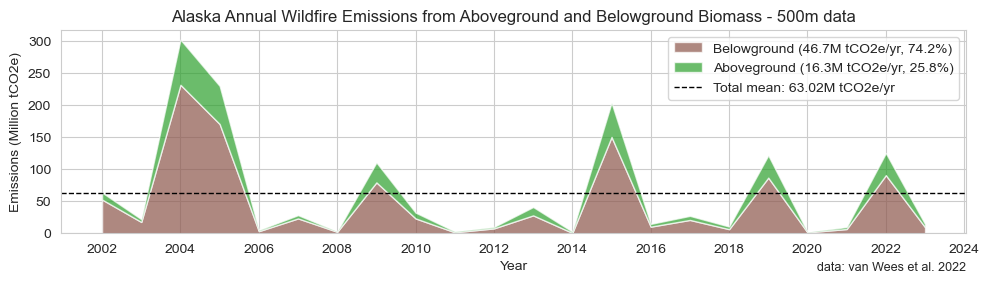

In [ ]:
# Stacked line plot of C_AG_TOT_VanWees and C_BG_TOT_VanWees, with long-term averages
cols = ["C_AG_TOT_VanWees500m", "C_BG_TOT_VanWees500m"]
de_e = df[["year"] + cols].dropna(subset=cols, how="all").copy()
de_e = de_e.sort_values("year")
ag = de_e["C_AG_TOT_VanWees500m"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
bg = de_e["C_BG_TOT_VanWees500m"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
years = de_e["year"]

# Stacked line plot
plt.figure(figsize=(10, 3))
ag_mean = ag.mean()
bg_mean = bg.mean()
plt.stackplot(
    years,
    bg,
    ag,
    labels=[
        f"Belowground ({bg_mean:,.1f}M tCO2e/yr, {bg_mean / (ag_mean + bg_mean):.1%})",
        f"Aboveground ({ag_mean:,.1f}M tCO2e/yr, {ag_mean / (ag_mean + bg_mean):.1%})",
    ],
    alpha=0.7,
    colors=["tab:brown", "tab:green"],
)
# Long-term averages
plt.axhline(
    bg_mean + ag_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {bg_mean + ag_mean:,.2f}M tCO2e/yr",
)
plt.title("Alaska Annual Wildfire Emissions from Aboveground and Belowground Biomass - 500m data")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.legend(loc="upper right")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

# Add annotation in lower right
plt.annotate(
    "data: van Wees et al. 2022",
    xy=(1, -0.2),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_wildfire_emissions_vanwees.png")
plt.show()


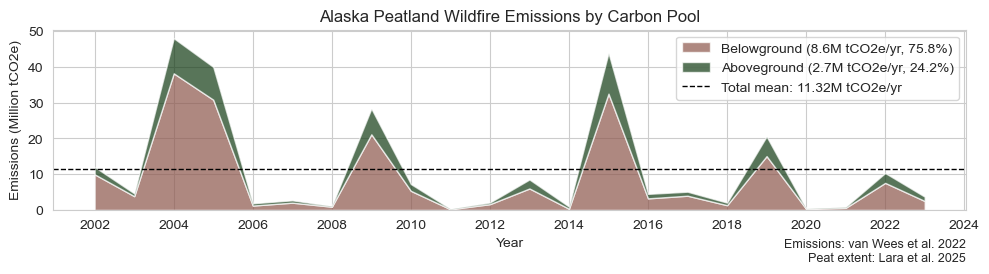

In [ ]:
# Stacked line plot of C_AG_TOT_VanWees and C_BG_TOT_VanWees, with long-term averages
cols = ["C_AG_TOT_VanWees500m_peat", "C_BG_TOT_VanWees500m_peat"]
de_e = df[["year"] + cols].dropna(subset=cols, how="all").copy()
de_e = de_e.sort_values("year")
ag = de_e["C_AG_TOT_VanWees500m_peat"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
bg = de_e["C_BG_TOT_VanWees500m_peat"].fillna(0) / 1000000000000 * 44 / 12  # gC to Mt CO2e
years = de_e["year"]

# Stacked line plot
plt.figure(figsize=(10, 3))
ag_mean = ag.mean()
bg_mean = bg.mean()
plt.stackplot(
    years,
    bg,
    ag,
    labels=[
        f"Belowground ({bg_mean:,.1f}M tCO2e/yr, {bg_mean / (ag_mean + bg_mean):.1%})",
        f"Aboveground ({ag_mean:,.1f}M tCO2e/yr, {ag_mean / (ag_mean + bg_mean):.1%})",
    ],
    alpha=0.7,
    colors=["tab:brown", "#113A13"],
)
# Long-term averages
plt.axhline(
    bg_mean + ag_mean,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Total mean: {bg_mean + ag_mean:,.2f}M tCO2e/yr",
)
plt.title("Alaska Peatland Wildfire Emissions by Carbon Pool")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.legend(loc="upper right")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

# Add annotation in lower right
plt.annotate(
    "Emissions: van Wees et al. 2022\n" \
    "Peat extent: Lara et al. 2025",
    xy=(1, -0.3),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_wildfire_emissions_vanwees.png")
plt.show()


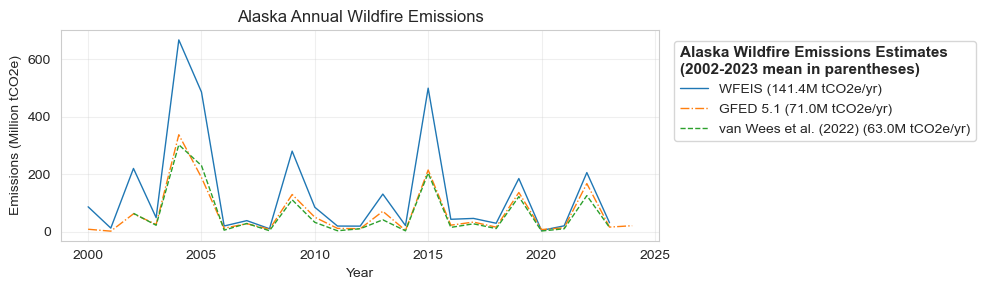

Mean WFEIS emissions 2002-2023: 141,352,910 (+- 78,041,229) tCO2e/yr
Mean GFED emissions 2002-2023: 70,974,405 (+- 36,866,833) tCO2e/yr
Mean van Wees emissions 2002-2023: 62,979,087 (+- 35,480,635) tCO2e/yr


In [15]:
# Compare emissions from WFEIS, GFED, and van Wees (similar to cell 6 for burned area)
import matplotlib.pyplot as plt

# Prepare emissions data
df_emissions_comp = df[
    ["year", "emissions_c_g_WFEIS", "C_AG_TOT_VanWees", "C_BG_TOT_VanWees", "C_GFED5.1_monthly"]
].copy()

# Calculate van Wees total (AG + BG)
df_emissions_comp["C_TOT_VanWees"] = (
    df_emissions_comp["C_AG_TOT_VanWees"] + df_emissions_comp["C_BG_TOT_VanWees"]
)

# Convert all to Million tonnes CO2e: multiply by 44/12 (C to CO2) and divide by 1e12 (g to Mt)
df_emissions_comp["WFEIS_MtCO2e"] = df_emissions_comp["emissions_c_g_WFEIS"] * 44 / 12 / 1e3
df_emissions_comp["VanWees_MtCO2e"] = df_emissions_comp["C_TOT_VanWees"] * 44 / 12 / 1e12
df_emissions_comp["GFED_MtCO2e"] = df_emissions_comp["C_GFED5.1_monthly"] * 44 / 12 / 1e12

# Filter for years and drop missing
df_emissions_comp = df_emissions_comp[(df_emissions_comp["year"] >= 2000) & (df_emissions_comp["year"] <= 2024)]
df_emissions_comp = df_emissions_comp.dropna(subset=["WFEIS_MtCO2e", "VanWees_MtCO2e", "GFED_MtCO2e"], how="all")

# Calculate means for legend (only 2002-2023)
means_period = df_emissions_comp[(df_emissions_comp["year"] >= 2002) & (df_emissions_comp["year"] <= 2023)]
mean_wfeis = means_period["WFEIS_MtCO2e"].mean()
mean_vanwees = means_period["VanWees_MtCO2e"].mean()
mean_gfed = means_period["GFED_MtCO2e"].mean()

# Create plot
plt.figure(figsize=(10, 3))
linestyles = ["-", "--", "-."]

plt.plot(
    df_emissions_comp["year"],
    df_emissions_comp["WFEIS_MtCO2e"],
    label=f"WFEIS ({mean_wfeis:.1f}M tCO2e/yr)",
    linestyle=linestyles[0],
    linewidth=1,
)
plt.plot(
    df_emissions_comp["year"],
    df_emissions_comp["GFED_MtCO2e"],
    label=f"GFED 5.1 ({mean_gfed:.1f}M tCO2e/yr)",
    linestyle=linestyles[2],
    linewidth=1,
)
plt.plot(
    df_emissions_comp["year"],
    df_emissions_comp["VanWees_MtCO2e"],
    label=f"van Wees et al. (2022) ({mean_vanwees:.1f}M tCO2e/yr)",
    linestyle=linestyles[1],
    linewidth=1,
)

plt.title("Alaska Annual Wildfire Emissions")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.025, 0.95),
    borderaxespad=0.0,
    fontsize=10,
    title="Alaska Wildfire Emissions Estimates\n(2002-2023 mean in parentheses)",
    title_fontproperties={"weight": "bold", "size": 11},
    alignment="left"
)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("outputs") / "plots" / "alaska_emissions_comparison_report.png", dpi=300, bbox_inches="tight")
plt.show()

# Calculate means 
means_period2 = df_emissions_comp[
    (df_emissions_comp["year"] >= 2002) & (df_emissions_comp["year"] <= 2023)
]
wfeis2 = means_period2["WFEIS_MtCO2e"]
vanwees2 = means_period2["VanWees_MtCO2e"]
gfed2 = means_period2["GFED_MtCO2e"]

ci95_peat = 1.96 * wfeis2.std() / np.sqrt(len(wfeis2))
ci95_vanwees = 1.96 * vanwees2.std() / np.sqrt(len(vanwees2))
ci95_gfed = 1.96 * gfed2.std() / np.sqrt(len(gfed2))

print(f"Mean WFEIS emissions 2002-2023: {wfeis2.mean() * 1e6:,.0f} (+- {ci95_peat * 1e6:,.0f}) tCO2e/yr")
print(f"Mean GFED emissions 2002-2023: {gfed2.mean() * 1e6:,.0f} (+- {ci95_gfed * 1e6:,.0f}) tCO2e/yr")
print(f"Mean van Wees emissions 2002-2023: {vanwees2.mean() * 1e6:,.0f} (+- {ci95_vanwees * 1e6:,.0f}) tCO2e/yr")

In [25]:
# Save aggregated data and run simple checks
out_csv = Path("outputs") / "burned_area_by_source_yearly.csv"
df_ba.to_csv(out_csv)
print("Saved aggregated CSV to", out_csv)

Saved aggregated CSV to outputs\burned_area_by_source_yearly.csv


In [43]:
# Calculate and plot emissions time series from vanwees_500m peat and total burned area
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# IPCC Input parameters for peat (same as before)
dry_matter_per_ha_peat = 66000  # kg DM/ha for peat
co2_per_kg_dm_peat = 362 * 44 / 12  # grams/kg for peat
ch4_per_kg_dm_peat = 9  # grams/kg for peat

# Standard upland forest parameters
dry_matter_per_ha_upland = 55000  # kg DM/ha (approximate)
co2_per_kg_dm_upland = 360 * 44 / 12  # grams/kg
ch4_per_kg_dm_upland = 4.5  # grams/kg (lower than peat)

# Global Warming Potentials (100-year)
gwp_co2 = 1
gwp_ch4 = 27

# Load data from vanwees_500m
df_vw500m_emissions = df[["burned_area_ha_VanWees500m", "burned_area_ha_VanWees500m_peat", "year"]].copy()
df_vw500m_emissions = df_vw500m_emissions.rename(
    columns={
        "burned_area_ha_VanWees500m": "total_area_ha",
        "burned_area_ha_VanWees500m_peat": "peat_area_ha",
    }
)
df_vw500m_emissions = df_vw500m_emissions.set_index("year").sort_index()

# Calculate emissions for each year
vw500m_emissions_data = []

for year in df_vw500m_emissions.index:
    peat_area_ha = df_vw500m_emissions.loc[year, "peat_area_ha"]
    total_area_ha = df_vw500m_emissions.loc[year, "total_area_ha"]
    upland_area_ha = total_area_ha - peat_area_ha

    # Peat emissions
    peat_dm_kg = peat_area_ha * dry_matter_per_ha_peat
    peat_co2_g = peat_dm_kg * co2_per_kg_dm_peat
    peat_ch4_g = peat_dm_kg * ch4_per_kg_dm_peat
    peat_co2_co2e = (peat_co2_g / 1e6) * gwp_co2
    peat_ch4_co2e = (peat_ch4_g / 1e6) * gwp_ch4
    peat_total_co2e = peat_co2_co2e + peat_ch4_co2e

    # Upland emissions
    upland_dm_kg = upland_area_ha * dry_matter_per_ha_upland
    upland_co2_g = upland_dm_kg * co2_per_kg_dm_upland
    upland_ch4_g = upland_dm_kg * ch4_per_kg_dm_upland
    upland_co2_co2e = (upland_co2_g / 1e6) * gwp_co2
    upland_ch4_co2e = (upland_ch4_g / 1e6) * gwp_ch4
    upland_total_co2e = upland_co2_co2e + upland_ch4_co2e

    # Total
    total_co2e = peat_total_co2e + upland_total_co2e

    vw500m_emissions_data.append(
        {
            "year": year,
            "total_area_ha": total_area_ha,
            "peat_area_ha": peat_area_ha,
            "upland_area_ha": upland_area_ha,
            "peat_tCO2e": peat_total_co2e,
            "upland_tCO2e": upland_total_co2e,
            "total_tCO2e": total_co2e,
        }
    )

vw500m_emissions_df = pd.DataFrame(vw500m_emissions_data)

# Save emissions data to CSV
vw500m_emissions_df.to_csv("outputs/vanwees_500m_emissions_from_burned_area.csv", index=False)
print("\nSaved vanwees_500m emissions data to vanwees_500m_emissions_from_burned_area.csv")


Saved vanwees_500m emissions data to vanwees_500m_emissions_from_burned_area.csv


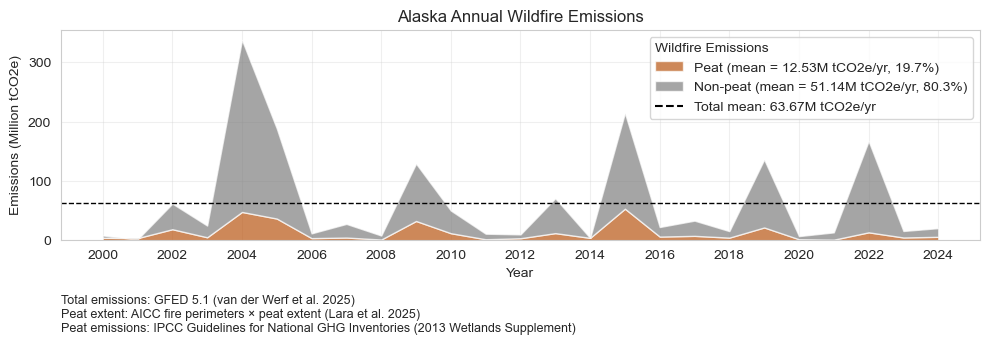

In [276]:
# Combine peat emissions from IPCC (cell 10) with total van Wees emissions (cell 12)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Prepare emissions data combining IPCC peat calculations with van Wees total
cols = ["C_GFED5.1_monthly"]
df_e = df[["year"] + cols].dropna(subset=cols, how="all").copy()
de_e = df_e.sort_values("year")
de_e = de_e[de_e["year"] >= 2000]

# Get van Wees total emissions (AG + BG converted to CO2e)
e_total_co2e = de_e["C_GFED5.1_monthly"] / 1e12 * 44 / 12

# Get peat emissions from IPCC calculations (cell 10)
df_peat_emissions = emissions_df.copy()
df_peat_emissions = df_peat_emissions[df_peat_emissions["year"] >= 2000]
peat_co2e = df_peat_emissions["peat_tCO2e"] / 1e6  # Convert to Mt CO2e

# Merge the datasets on year
df_combined = de_e.merge(df_peat_emissions[["year", "peat_tCO2e"]], on="year", how="inner")
df_combined["total_co2e"] = e_total_co2e.values
df_combined["peat_co2e_Mt"] = df_combined["peat_tCO2e"] / 1e6
df_combined["non_peat_co2e_Mt"] = df_combined["total_co2e"] - df_combined["peat_co2e_Mt"]

# Calculate averages
avg_peat_co2e = df_combined["peat_co2e_Mt"].mean()
avg_non_peat_co2e = df_combined["non_peat_co2e_Mt"].mean()
avg_total_co2e = df_combined["total_co2e"].mean()
peat_pct = 100 * (avg_peat_co2e / avg_total_co2e)
non_peat_pct = 100 * (avg_non_peat_co2e / avg_total_co2e)

# Create figure with two subplots
plt.subplots(figsize=(10, 3))

# Plot 1: Stacked area chart of emissions (peat from IPCC + non-peat from van Wees)
plt.stackplot(
    df_combined["year"],
    df_combined["peat_co2e_Mt"],
    df_combined["non_peat_co2e_Mt"],
    alpha=0.7,
    colors=["#B95613", "tab:gray"],
)

# Long-term averages
plt.axhline(
    avg_total_co2e,
    color="black",
    linestyle="--",
    linewidth=1
)

# Custom legend with mean values and percentages
legend_elements = [
    Patch(
        facecolor="#B95613",
        alpha=0.7,
        label=f"Peat (mean = {avg_peat_co2e:,.2f}M tCO2e/yr, {peat_pct:.1f}%)",
    ),
    Patch(
        facecolor="tab:gray",
        alpha=0.7,
        label=f"Non-peat (mean = {avg_non_peat_co2e:,.2f}M tCO2e/yr, {non_peat_pct:.1f}%)",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        label=f"Total mean: {avg_total_co2e:,.2f}M tCO2e/yr",
    ),
]

plt.legend(
    handles=legend_elements,
    loc="upper right",
    title="Wildfire Emissions",
    alignment="left",
)

plt.title("Alaska Annual Wildfire Emissions")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()

# Add annotations
plt.annotate(
    "Total emissions: GFED 5.1 (van der Werf et al. 2025)\n" \
    "Peat extent: AICC fire perimeters × peat extent (Lara et al. 2025)\n" \
    "Peat emissions: IPCC Guidelines for National GHG Inventories (2013 Wetlands Supplement)",
    xy=(0, -0.45),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=9,
)

plt.savefig(Path("outputs") / "plots" / "peat_vs_alaska_emissions.png", dpi=300, bbox_inches="tight")
plt.show()


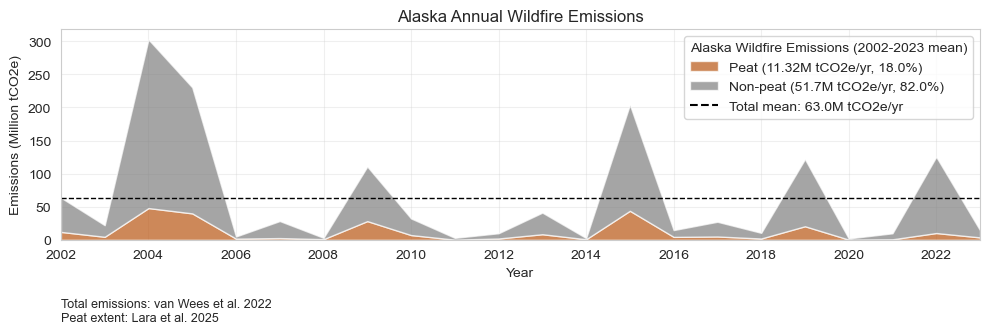


van Wees 500m Emissions (2002-2023):
Peat: 11.32M tCO2e/yr (18.0%)
  Standard deviation: ±14.99M tCO2e
  95% confidence interval: ±6.26M tCO2e

Total: 63.02M tCO2e/yr
  Standard deviation: ±84.95M tCO2e
  95% confidence interval: ±35.50M tCO2e


In [291]:
# Van Wees 500m emissions partitioned into peat and non-peat (similar to cell 19)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Prepare emissions data from van Wees 500m (total and peat)
cols_total = ["C_AG_TOT_VanWees500m", "C_BG_TOT_VanWees500m"]
cols_peat = ["C_AG_TOT_VanWees500m_peat", "C_BG_TOT_VanWees500m_peat"]

df_vw500 = df[["year"] + cols_total + cols_peat].dropna(subset=cols_total + cols_peat, how="all").copy()
df_vw500 = df_vw500.sort_values("year")
df_vw500 = df_vw500[df_vw500["year"] >= 2000]

# Calculate total emissions (AG + BG) for both total and peat
df_vw500["total_co2e"] = (
    (df_vw500["C_AG_TOT_VanWees500m"] + df_vw500["C_BG_TOT_VanWees500m"]) * 44 / 12 / 1e12
)
df_vw500["peat_co2e"] = (
    (df_vw500["C_AG_TOT_VanWees500m_peat"] + df_vw500["C_BG_TOT_VanWees500m_peat"]) * 44 / 12 / 1e12
)
df_vw500["non_peat_co2e"] = df_vw500["total_co2e"] - df_vw500["peat_co2e"]

# Calculate averages
avg_peat_co2e = df_vw500["peat_co2e"].mean()
avg_non_peat_co2e = df_vw500["non_peat_co2e"].mean()
avg_total_co2e = df_vw500["total_co2e"].mean()
peat_pct = 100 * (avg_peat_co2e / avg_total_co2e)
non_peat_pct = 100 * (avg_non_peat_co2e / avg_total_co2e)

# Create figure
plt.subplots(figsize=(10, 3))

# Stacked area chart of emissions (peat + non-peat from van Wees 500m)
plt.stackplot(
    df_vw500["year"],
    df_vw500["peat_co2e"],
    df_vw500["non_peat_co2e"],
    alpha=0.7,
    colors=["#B95613", "tab:gray"],
)

# Long-term average line
plt.axhline(
    avg_total_co2e,
    color="black",
    linestyle="--",
    linewidth=1
)

# Custom legend with mean values and percentages
legend_elements = [
    Patch(
        facecolor="#B95613",
        alpha=0.7,
        label=f"Peat ({avg_peat_co2e:,.2f}M tCO2e/yr, {peat_pct:.1f}%)",
    ),
    Patch(
        facecolor="tab:gray",
        alpha=0.7,
        label=f"Non-peat ({avg_non_peat_co2e:,.1f}M tCO2e/yr, {non_peat_pct:.1f}%)",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        label=f"Total mean: {avg_total_co2e:,.1f}M tCO2e/yr",
    ),
]

plt.legend(
    handles=legend_elements,
    loc="upper right",
    title="Alaska Wildfire Emissions (2002-2023 mean)",
    alignment="left",
)
plt.xlim(2002, 2023)
plt.title("Alaska Annual Wildfire Emissions")
plt.ylabel("Emissions (Million tCO2e)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()

# Add annotations
plt.annotate(
    "Total emissions: van Wees et al. 2022\n" \
    "Peat extent: Lara et al. 2025",
    xy=(0, -0.4),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=9,
)

plt.savefig(Path("outputs") / "plots" / "vanwees500m_peat_vs_total_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

# Filter for 2002-2023 period for statistics
df_vw500_stats = df_vw500[(df_vw500["year"] >= 2002) & (df_vw500["year"] <= 2023)]

# Calculate statistics for 2002-2023
mean_peat_2002_2023 = df_vw500_stats["peat_co2e"].mean()
std_peat = df_vw500_stats["peat_co2e"].std()
mean_total_2002_2023 = df_vw500_stats["total_co2e"].mean()
std_total = df_vw500_stats["total_co2e"].std()

# 95% confidence intervals (mean ± 1.96 * std / sqrt(n))
n = len(df_vw500_stats)
ci95_peat = 1.96 * std_peat / np.sqrt(n)
ci95_total = 1.96 * std_total / np.sqrt(n)

print("\nvan Wees 500m Emissions (2002-2023):")
print(f"Peat: {mean_peat_2002_2023:.2f}M tCO2e/yr ({peat_pct:.1f}%)")
print(f"  Standard deviation: ±{std_peat:.2f}M tCO2e")
print(f"  95% confidence interval: ±{ci95_peat:.2f}M tCO2e")
print(f"\nTotal: {mean_total_2002_2023:.2f}M tCO2e/yr")
print(f"  Standard deviation: ±{std_total:.2f}M tCO2e")
print(f"  95% confidence interval: ±{ci95_total:.2f}M tCO2e")